In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../../")



import scipy.stats as stats
import statsmodels.api as sm
from scipy.io import loadmat
from scipy.stats import wilcoxon
from scipy.stats import sem
from statsmodels.stats.multitest import fdrcorrection
import statsmodels.formula.api as smf

from scipy.io import savemat
import pickle as pkl

In [2]:
##For MEG
##modeled data
x_mi_all={}
x_base_all={}
x_rest_all={}

for num in range(1, 5):
    x_mi_all[num]=np.zeros((68, 10, 19))
    x_base_all[num]=np.zeros((68, 10, 19))
    x_rest_all[num]=np.zeros((68, 10, 19))
    
    for i in range(19):
        mi_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/mi_allsubs_f/mi_nostim_mse_db_fvec330_{i}.p'
        with open(mi_fname, 'rb') as f:
            x_mi_all[num][:,:,i]=np.array(pkl.load(f))

        base_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/baseline_allsubs_f/baseline_nostim_mse_db_fvec330_{i}.p'
        with open(base_fname, 'rb') as f:
            x_base_all[num][:,:,i] = np.array(pkl.load(f))
        
        rest_fname = f'../../bci_results_apd/bci_results/meg/sess{num}/rs1_allsubs_f0/rs1_nostim_mse_db_fvec330_{i}.p'
        with open(rest_fname, 'rb') as f:
            x_rest_all[num][:,:,i]=np.array(pkl.load(f))


In [3]:
# All regions
df=pd.read_excel('../../ListROIs_DK.xlsx')
all_regions=[]
all_regions_idx=[]
for i,r in df.iterrows():
    print(i, r['ROI'].strip("'"))
    all_regions_idx.append(i)
    all_regions.append(r['ROI'].strip("'"))

0 bankssts L
1 bankssts R
2 caudalanteriorcingulate L
3 caudalanteriorcingulate R
4 caudalmiddlefrontal L
5 caudalmiddlefrontal R
6 cuneus L
7 cuneus R
8 entorhinal L
9 entorhinal R
10 frontalpole L
11 frontalpole R
12 fusiform L
13 fusiform R
14 inferiorparietal L
15 inferiorparietal R
16 inferiortemporal L
17 inferiortemporal R
18 insula L
19 insula R
20 isthmuscingulate L
21 isthmuscingulate R
22 lateraloccipital L
23 lateraloccipital R
24 lateralorbitofrontal L
25 lateralorbitofrontal R
26 lingual L
27 lingual R
28 medialorbitofrontal L
29 medialorbitofrontal R
30 middletemporal L
31 middletemporal R
32 paracentral L
33 paracentral R
34 parahippocampal L
35 parahippocampal R
36 parsopercularis L
37 parsopercularis R
38 parsorbitalis L
39 parsorbitalis R
40 parstriangularis L
41 parstriangularis R
42 pericalcarine L
43 pericalcarine R
44 postcentral L
45 postcentral R
46 posteriorcingulate L
47 posteriorcingulate R
48 precentral L
49 precentral R
50 precuneus L
51 precuneus R
52 ros

In [ ]:
motor_areas=[
    'precentral L', 'precentral R', 'postcentral L', 'postcentral R',
    'paracentral L', 'paracentral R'
]

# Get indices for motor/parietal regions
mp_indices = [i for i, name in enumerate(all_regions) if name in motor_areas]

In [5]:
mp_indices

[32, 33, 44, 45, 48, 49]

In [6]:
## BCI scores
scores=loadmat("../../Performances_19Subj_4Sess.mat")
bci_score={}
for i in range(1,5):
    bci_score[i]=np.concatenate([arr.flatten() for arr in np.squeeze(loadmat("../../Performances_19Subj_4Sess.mat")[f'Performance_Sess{i}'])])

In [7]:
bci_score

{1: array([73.8 , 45.  , 66.1 , 51.7 , 61.2 , 54.4 , 59.4 , 52.8 , 42.2 ,
        53.9 , 47.22, 53.3 , 54.17, 60.  , 76.1 , 48.33, 56.  , 53.89,
        45.  ]),
 2: array([90.2 , 35.6 , 61.7 , 51.7 , 50.6 , 58.9 , 66.11, 50.  , 45.6 ,
        45.  , 52.22, 65.6 , 50.  , 68.9 , 70.6 , 61.67, 63.89, 53.89,
        57.22]),
 3: array([86.6 , 38.9 , 72.8 , 61.7 , 79.3 , 51.7 , 56.67, 68.9 , 58.9 ,
        55.6 , 47.78, 57.8 , 60.  , 76.1 , 53.9 , 66.  , 72.  , 52.78,
        58.33]),
 4: array([89.3 , 38.1 , 86.1 , 63.9 , 88.9 , 56.7 , 70.  , 60.  , 66.1 ,
        63.3 , 53.9 , 77.2 , 69.17, 80.  , 61.1 , 71.  , 73.  , 68.33,
        56.67])}

In [8]:
x_mi_all[4][len(mp_indices),2,:].shape

(19,)

In [ ]:
motor_idx = [32, 33, 44, 45, 48, 49]
n_motor = len(motor_idx)

# n_regions = 68
n_subjects = 19
taue_mi_dict = {}
taue_rest_dict = {}

records = []
for sess in [1, 2, 3, 4]:
    scores = bci_score[sess]
    mi_data = x_mi_all[sess][[32, 33, 44, 45, 48, 49], 2,:]     # Shape (6, 19)
    rest_data = x_rest_all[sess][[32, 33, 44, 45, 48, 49], 2,:]  # Shape (6, 19)

    for subj_idx in range(n_subjects):
        row = {
            'Subject': f'Subj_{subj_idx+1}',
            'Session': sess,
            'BCI_Score': scores[subj_idx]
        }
        # Add taue for every region
        for roi in range(n_motor):
            row[f'Taue_MI_ROI{roi}'] = mi_data[roi, subj_idx]
            row[f'Taue_Rest_ROI{roi}'] = rest_data[roi, subj_idx]
            row[f'Taue_Diff_ROI{roi}'] = (mi_data[roi, subj_idx]/rest_data[roi, subj_idx]-1)
            
        records.append(row)

df_motor = pd.DataFrame(records)
print(f"Dataframe prepared. Shape: {df.shape} (Rows: 76 [19*4], Cols: Features)")


Dataframe prepared. Shape: (68, 2) (Rows: 76 [19*4], Cols: Features)


In [10]:
df_motor

,Subject,Session,BCI_Score,Taue_MI_ROI0,Taue_Rest_ROI0,Taue_Diff_ROI0,Taue_MI_ROI1,Taue_Rest_ROI1,Taue_Diff_ROI1,Taue_MI_ROI2,...,Taue_Diff_ROI2,Taue_MI_ROI3,Taue_Rest_ROI3,Taue_Diff_ROI3,Taue_MI_ROI4,Taue_Rest_ROI4,Taue_Diff_ROI4,Taue_MI_ROI5,Taue_Rest_ROI5,Taue_Diff_ROI5
0,Subj_1,1,73.80,12.663158,13.343273,-0.050971,19.545893,22.725179,-0.139901,11.625169,...,0.016956,10.907023,11.303293,-0.035058,19.869283,27.013886,-0.264479,17.437609,23.559391,-0.259845
1,Subj_2,1,45.00,10.044408,13.064639,-0.231176,30.000000,12.983393,1.310644,5.396637,...,-0.620123,5.247066,12.963756,-0.595251,5.181770,12.418439,-0.582736,24.991319,11.307986,1.210059
2,Subj_3,1,66.10,16.204961,18.606680,-0.129078,14.891853,16.097798,-0.074914,12.987384,...,-0.212364,7.089794,14.648496,-0.516005,7.447091,8.434722,-0.117091,7.825916,17.151081,-0.543707
3,Subj_4,1,51.70,7.228041,14.786012,-0.511157,7.046935,12.687530,-0.444578,10.377885,...,-0.316395,9.229789,12.756349,-0.276455,7.647281,12.513147,-0.388860,9.913247,17.050043,-0.418579
4,Subj_5,1,61.20,12.477149,16.248101,-0.232086,12.495020,15.719903,-0.205146,12.550977,...,-0.190365,6.526200,15.065505,-0.566812,12.724986,16.685894,-0.237381,6.413717,15.372986,-0.582793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Subj_15,4,61.10,21.806362,22.852816,-0.045791,9.937197,21.183778,-0.530905,5.000000,...,-0.758473,15.868469,18.593275,-0.146548,5.000000,30.000000,-0.833333,21.316779,23.275235,-0.084143
72,Subj_16,4,71.00,20.081733,21.950787,-0.085147,21.209273,21.978538,-0.035001,19.942778,...,-0.043975,20.120194,21.774319,-0.075967,21.592159,21.686398,-0.004346,19.997123,29.996147,-0.333344
73,Subj_17,4,73.00,12.874853,11.390246,0.130340,13.026781,10.916240,0.193340,15.224261,...,-0.166015,5.836183,18.852346,-0.690427,15.845721,19.044554,-0.167966,13.220852,18.600264,-0.289212
74,Subj_18,4,68.33,7.203423,30.000000,-0.759886,7.174431,30.000000,-0.760852,6.710473,...,-0.048348,5.000000,7.576984,-0.340107,30.000000,7.119335,3.213877,6.866302,7.490165,-0.083291


In [35]:

# # 4. ANALYSIS B: LINEAR MIXED EFFECTS (LMM)
# # (Best for Repeated Measures / Longitudinal Data)

# print("Model: BCI_Score ~ Taue + Session + (1|Subject)")

# lme_results = []
# for roi in range(n_motor):
#     # standardize variables to make coefficients comparable
#     formula = f"BCI_Score ~ Taue_MI_ROI{roi} + C(Session)"
    
#     # Fit LME model
#     md = smf.mixedlm(formula, df_motor, groups=df["Subject"])
#     mdf = md.fit(reml=False)
    
#     # Extract coefficient and p-value for Taue
#     coef = mdf.params[f"Taue_MI_ROI{roi}"]
#     pval = mdf.pvalues[f"Taue_MI_ROI{roi}"]
    
#     lme_results.append({'ROI': roi, 'LME_Coef': coef, 'LME_Pval': pval})

# df_lme = pd.DataFrame(lme_results)
# df_lme['LME_Pval_FDR'] = fdrcorrection(df_lme['LME_Pval'])[1]

# print("Top ROIs where Taue predicts BCI Score accounting for subject variance:")
# print(df_lme.sort_values(by='LME_Pval').head(5))



In [12]:
# #find region with lowest p-value
# for roi in range(n_motor):
#     if roi not in df_lme['ROI'].values:
#         continue
#     pval = df_lme.loc[df_lme['ROI'] == roi, 'LME_Pval'].values[0]
#     if pval < 0.05:
#         min_pval = pval
#         best_roi = roi
#         print(f"Significant ROI: {all_regions[mp_indices[roi]]} with p-value: {pval}")


In [13]:
# ##WITH TAUE DIFFERENCE
# # 4. ANALYSIS B: LINEAR MIXED EFFECTS (LME)
# # (Best for Repeated Measures / Longitudinal Data)

# print("\n--- Analysis B: Linear Mixed Effects Models (Top ROIs) ---")
# print("Model: BCI_Score ~ Taue + Session + (1|Subject)")

# lme_results = []
# for roi in range(n_motor):
#     # We standardize variables to make coefficients comparable
#     formula = f"BCI_Score ~ Taue_MI_ROI{roi} + C(Session)"
    
#     # Fit LME model
#     md = smf.mixedlm(formula, df, groups=df["Subject"])
#     mdf = md.fit(reml=False)
    
#     # Extract coefficient and p-value for Taue
#     coef = mdf.params[f"Taue_MI_ROI{roi}"]
    
#     pval = mdf.pvalues[f"Taue_MI_ROI{roi}"]

#     lme_results.append({'ROI': roi, 'LME_Coef': coef, 'LME_Pval': pval})

# df_lme = pd.DataFrame(lme_results)
# df_lme['LME_Pval_FDR'] = fdrcorrection(df_lme['LME_Pval'])[1]

# print("Top ROIs where Taue predicts BCI Score accounting for subject variance:")
# print(df_lme.sort_values(by='LME_Pval'))



In [14]:
# best_roi = int(df_lme.sort_values(by='LME_Pval').iloc[0]['ROI'])
# best_roi

### Taue

In [32]:
## Going for all the regions

n_regions = 68
n_subjects = 19
taue_mi_dict = {}
taue_rest_dict = {}

records = []
for sess in [1, 2, 3, 4]:
    scores = bci_score[sess]
    mi_data = x_mi_all[sess][:, 2,:]     # Shape (68, 19)
    rest_data = x_rest_all[sess][:, 2,:]  # Shape (68, 19)

    for subj_idx in range(n_subjects):
        row = {
            'Subject': f'Subj_{subj_idx+1}',
            'Session': sess,
            'BCI_Score': scores[subj_idx]
        }
        # taue for every region
        for roi in range(n_regions):
            row[f'Taue_MI_ROI{roi}'] = mi_data[roi, subj_idx] #Mi taue 
            row[f'Taue_Rest_ROI{roi}'] = rest_data[roi, subj_idx] #Rest taue
            row[f'Taue_Diff_ROI{roi}'] = (mi_data[roi, subj_idx]/rest_data[roi, subj_idx]-1) #MI/RS-1 taue
            
        records.append(row)

df_all = pd.DataFrame(records)
print(f"Dataframe prepared. Shape: {df.shape} (Rows: 76 [19*4], Cols: Features)")


Dataframe prepared. Shape: (68, 2) (Rows: 76 [19*4], Cols: Features)


In [33]:
df_all.head(10)

,Subject,Session,BCI_Score,Taue_MI_ROI0,Taue_Rest_ROI0,Taue_Diff_ROI0,Taue_MI_ROI1,Taue_Rest_ROI1,Taue_Diff_ROI1,Taue_MI_ROI2,...,Taue_Diff_ROI64,Taue_MI_ROI65,Taue_Rest_ROI65,Taue_Diff_ROI65,Taue_MI_ROI66,Taue_Rest_ROI66,Taue_Diff_ROI66,Taue_MI_ROI67,Taue_Rest_ROI67,Taue_Diff_ROI67
0,Subj_1,1,73.8,10.962565,12.754246,-0.140477,11.758452,12.551500,-0.063183,16.515680,...,-0.125259,11.835822,30.000000,-0.605473,11.156271,11.820129,-0.056163,11.461629,12.801719,-0.104681
1,Subj_2,1,45.0,11.319965,13.741069,-0.176195,30.000000,13.593766,1.206894,5.000000,...,0.000000,30.000000,30.000000,0.000000,11.171318,12.297166,-0.091554,5.000000,13.649042,-0.633674
2,Subj_3,1,66.1,8.308024,16.845020,-0.506796,8.526039,16.915066,-0.495950,8.060030,...,-0.202296,13.869996,18.251141,-0.240048,8.020961,16.456250,-0.512589,8.825011,15.204868,-0.419593
3,Subj_4,1,51.7,7.107219,13.948741,-0.490476,6.661104,13.508629,-0.506900,13.651693,...,-0.505165,6.431820,15.780920,-0.592431,6.951082,13.152982,-0.471520,7.041789,15.808300,-0.554551
4,Subj_5,1,61.2,12.891656,17.202458,-0.250592,12.815723,16.360181,-0.216652,13.078937,...,-0.086143,14.646979,17.942338,-0.183664,13.145213,16.573089,-0.206834,13.516381,16.976511,-0.203819
5,Subj_6,1,54.4,13.799141,17.406804,-0.207256,13.713436,16.697876,-0.178732,13.728672,...,0.423314,30.000000,20.048157,0.496397,12.725402,16.651694,-0.235789,13.606737,19.269569,-0.293874
6,Subj_7,1,59.4,16.791782,15.305771,0.097088,5.494018,5.003163,0.098109,5.110539,...,0.029429,26.634613,5.000000,4.326923,15.723787,15.591276,0.008499,5.209893,5.000000,0.041979
7,Subj_8,1,52.8,9.148216,11.391745,-0.196943,11.608933,12.875090,-0.098342,21.562769,...,-0.455122,30.000000,30.000000,0.000000,6.315261,11.843123,-0.466757,18.251990,12.742921,0.432324
8,Subj_9,1,42.2,10.210654,16.629182,-0.385980,30.000000,13.937048,1.152536,23.603819,...,-0.289385,30.000000,14.296831,1.098367,13.167376,12.962679,0.015791,14.149573,13.410672,0.055098
9,Subj_10,1,53.9,11.585167,14.458536,-0.198732,6.746893,15.151905,-0.554717,13.102806,...,0.133997,17.706139,18.241040,-0.029324,11.128334,14.491516,-0.232079,6.315726,14.793499,-0.573074


In [ ]:

# LINEAR MIXED EFFECTS Models(LMM)--With Taue from all regions

print("Linear Mixed Effects Models (Top ROIs)")
print("Model: BCI_Score ~ Taue + Session + (1|Subject)")

#for each roi
lme_results = []
#does taue in this roi predict bci score while accounting for subject variance
for roi in range(n_regions):
    formula = f"BCI_Score ~ Taue_MI_ROI{roi} + C(Session)"

    # Fit LME model
    md = smf.mixedlm(formula, df_all, groups=df_all["Subject"])
    mdf = md.fit(reml=False)

    coef = mdf.params[f"Taue_MI_ROI{roi}"]
    pval = mdf.pvalues[f"Taue_MI_ROI{roi}"]

    lme_results.append({'ROI': roi, 'LME_Coef': coef, 'LME_Pval': pval})

df_lme = pd.DataFrame(lme_results)
df_lme['LME_Pval_FDR'] = fdrcorrection(df_lme['LME_Pval'])[1]

print("Top ROIs where Taue predicts BCI Score accounting for subject variance:")
print(df_lme.sort_values(by='LME_Pval').head(10))



Linear Mixed Effects Models (Top ROIs)
Model: BCI_Score ~ Taue + Session + (1|Subject)
Top ROIs where Taue predicts BCI Score accounting for subject variance:
    ROI  LME_Coef  LME_Pval  LME_Pval_FDR
16   16  0.538341  0.000218      0.014806
48   48  0.376468  0.019425      0.660450
11   11 -0.323383  0.058168      0.931291
35   35  0.273758  0.081471      0.931291
60   60 -0.369115  0.087842      0.931291
26   26  0.274418  0.094689      0.931291
17   17  0.211219  0.103945      0.931291
40   40 -0.260119  0.131648      0.931291
51   51 -0.523316  0.144323      0.931291
67   67 -0.499671  0.149561      0.931291


In [18]:
#find region with lowest p-value
for roi in range(n_regions):
    if roi not in df_lme['ROI'].values:
        continue
    pval = df_lme.loc[df_lme['ROI'] == roi, 'LME_Pval'].values[0]
    if pval < 0.05:
        min_pval = pval
        best_roi = roi
        print(f"Significant ROI: {all_regions[roi]} with p-value: {pval}")


Significant ROI: inferiortemporal L with p-value: 0.00021773664549465458
Significant ROI: precentral L with p-value: 0.019425014609361694


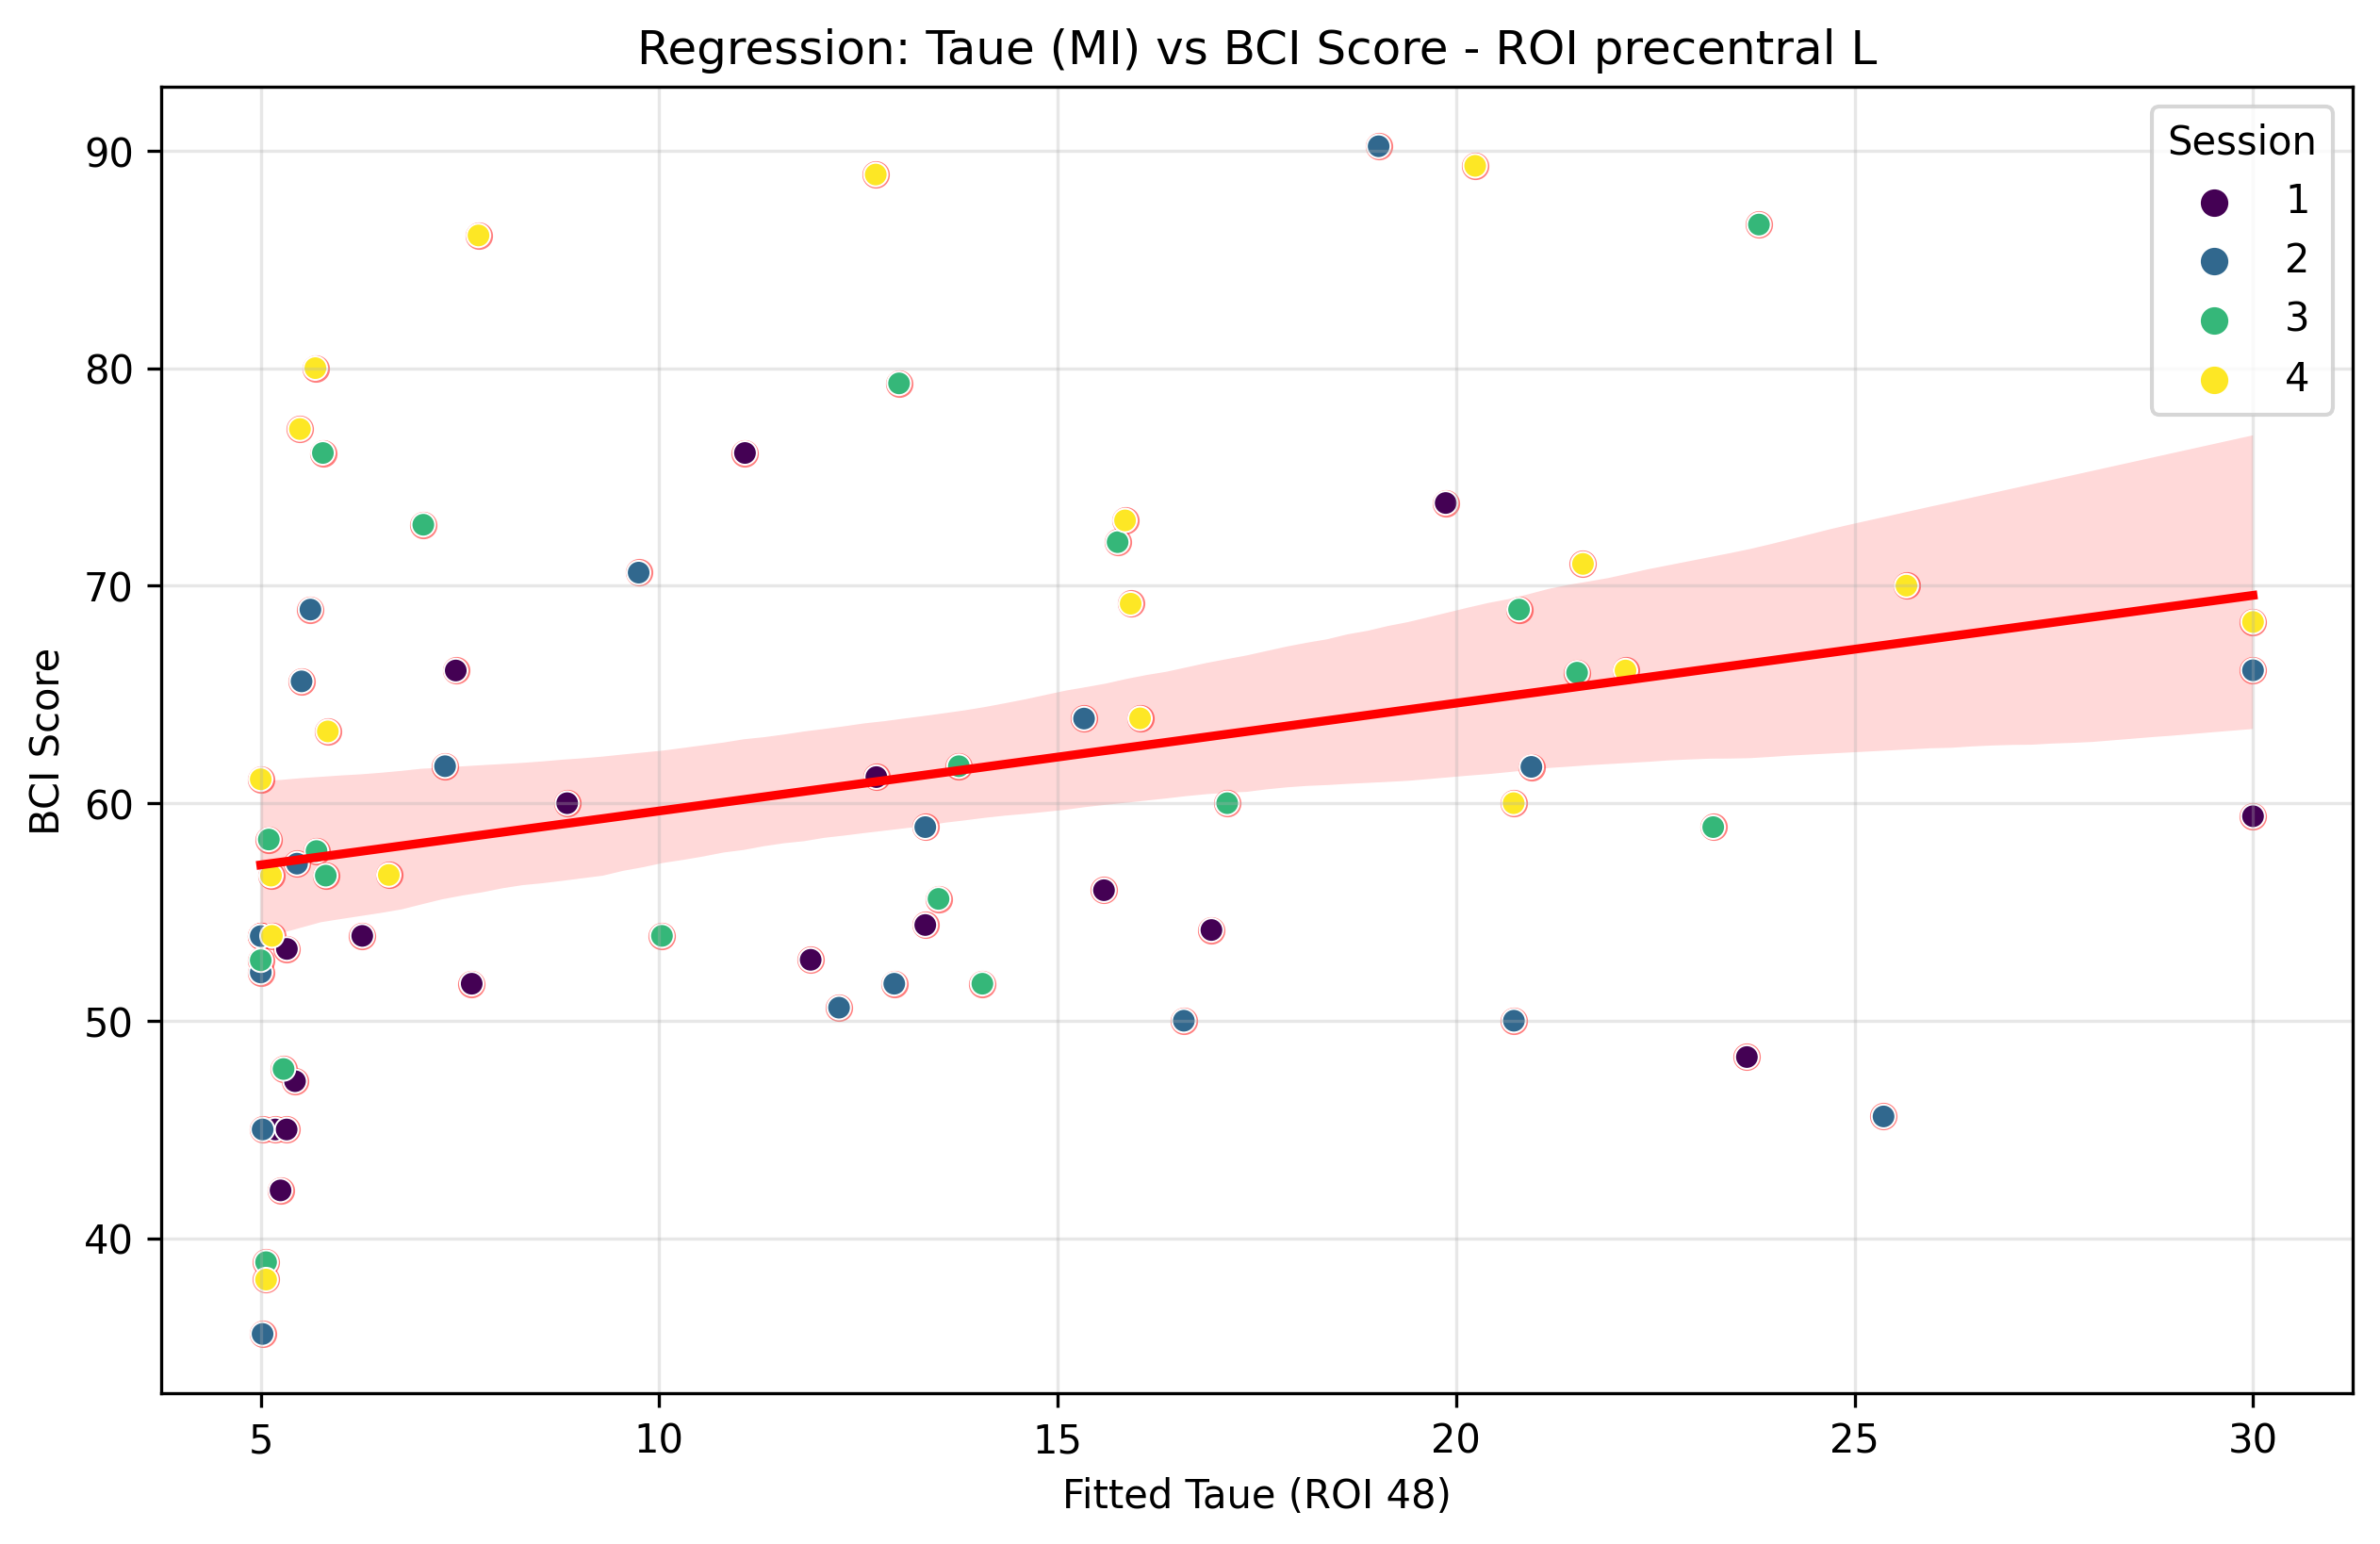

In [19]:
#  single best ROI found in LME analysis
# best_roi = df_lme.sort_values(by='LME_Pval').iloc[0]['ROI']
best_roi = 48

plt.figure(figsize=(10, 6), dpi=300)
## session-1 plot
# sns.regplot(data=df_all[df_all['Session']==1], x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', scatter_kws={'alpha':0.5}, label='Session 1 Data Points')
# sns.regplot(data=df_all[df_all['Session']==2], x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', scatter_kws={'alpha':0.5}, label='Session 2 Data Points')
# sns.regplot(data=df_all[df_all['Session']==3], x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', scatter_kws={'alpha':0.5}, label='Session 3 Data Points')
# sns.regplot(data=df_all[df_all['Session']==4], x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', scatter_kws={'alpha':0.5}, label='Session 4 Data Points')
sns.regplot(data=df_all, x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', scatter_kws={'alpha':0.5}, ci=95, color='red')
plt.title(f'Regression: Taue (MI) vs BCI Score - ROI {all_regions[best_roi]}')
plt.xlabel(f'Fitted Taue (ROI {best_roi})')
plt.ylabel('BCI Score')

sns.scatterplot(data=df_all, x=f'Taue_MI_ROI{best_roi}', y='BCI_Score', hue='Session', palette='viridis', legend='full')
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
## Going for all the regions- gei

n_regions = 68
n_subjects = 19
gei_mi_dict = {}
gei_rest_dict = {}

records = []
for sess in [1, 2, 3, 4]:
    scores = bci_score[sess]
    mi_data = x_mi_all[sess][:, 1,:]     # Shape (68, 19)
    rest_data = x_rest_all[sess][:, 1,:]  # Shape (68, 19)

    for subj_idx in range(n_subjects):
        row = {
            'Subject': f'Subj_{subj_idx+1}',
            'Session': sess,
            'BCI_Score': scores[subj_idx]
        }
        # taue for every region
        for roi in range(n_regions):
            row[f'Gei_MI_ROI{roi}'] = mi_data[roi, subj_idx] #Mi gei
            row[f'Gei_Rest_ROI{roi}'] = rest_data[roi, subj_idx] #Rest gei
            row[f'Gei_Diff_ROI{roi}'] = (mi_data[roi, subj_idx]/rest_data[roi, subj_idx]-1) #MI/RS-1 gei

        records.append(row)

df_all = pd.DataFrame(records)
print(f"Dataframe prepared. Shape: {df.shape} (Rows: 76 [19*4], Cols: Features)")


Dataframe prepared. Shape: (68, 2) (Rows: 76 [19*4], Cols: Features)


In [30]:
df_all.head(10)

,Subject,Session,BCI_Score,Gei_MI_ROI0,Gei_Rest_ROI0,Gei_Diff_ROI0,Gei_MI_ROI1,Gei_Rest_ROI1,Gei_Diff_ROI1,Gei_MI_ROI2,...,Gei_Diff_ROI64,Gei_MI_ROI65,Gei_Rest_ROI65,Gei_Diff_ROI65,Gei_MI_ROI66,Gei_Rest_ROI66,Gei_Diff_ROI66,Gei_MI_ROI67,Gei_Rest_ROI67,Gei_Diff_ROI67
0,Subj_1,1,73.8,0.236785,0.001000,235.784541,0.001000,0.001000,0.000000,0.008136,...,0.000000,0.001000,0.354743,-0.997181,0.437269,0.139292,2.139218,0.122508,0.001000,121.508288
1,Subj_2,1,45.0,0.046921,0.001000,45.920507,0.395586,0.001000,394.586210,0.460990,...,-0.693746,0.253517,0.351957,-0.279694,0.248656,0.001000,247.656293,0.546174,0.001000,545.174159
2,Subj_3,1,66.1,1.423502,0.721226,0.973726,0.829666,0.625641,0.326107,0.218340,...,0.000000,0.031349,0.129480,-0.757888,1.174139,0.698859,0.680080,0.716487,0.660281,0.085125
3,Subj_4,1,51.7,1.669511,0.487258,2.426340,1.633798,0.476464,2.429005,1.692474,...,1.723117,1.408991,1.900000,-0.258426,1.858103,0.533583,2.482315,1.650410,1.704028,-0.031465
4,Subj_5,1,61.2,0.480765,0.168895,1.846533,1.900000,0.181127,9.489859,0.401281,...,-0.942791,0.001000,0.001000,0.000000,0.433122,0.224835,0.926399,0.572939,0.130369,3.394736
5,Subj_6,1,54.4,0.437972,0.459777,-0.047425,0.615772,0.343243,0.793979,0.734848,...,-0.294103,1.138650,1.865453,-0.389612,0.635491,0.474764,0.338541,0.656347,1.809059,-0.637189
6,Subj_7,1,59.4,0.030820,0.725797,-0.957536,0.448045,0.001000,447.044928,0.265459,...,-0.216466,0.038410,0.001000,37.409741,0.001505,0.162766,-0.990751,0.271271,1.626271,-0.833195
7,Subj_8,1,52.8,0.214714,0.015398,12.944289,0.034687,0.001000,33.686960,0.437976,...,-0.998191,0.444158,0.295539,0.502873,0.357685,0.248700,0.438220,1.695804,0.001000,1694.803509
8,Subj_9,1,42.2,0.005486,0.001000,4.486303,0.467413,0.001000,466.412585,0.399091,...,-0.689029,0.173454,0.001000,172.453541,0.001369,0.073197,-0.981300,0.016438,0.001000,15.437827
9,Subj_10,1,53.9,0.674876,0.573206,0.177371,0.222058,0.636506,-0.651130,1.104723,...,0.000000,0.001000,0.006372,-0.843066,0.799464,0.572795,0.395724,0.211607,0.757318,-0.720584


In [31]:
# LINEAR MIXED EFFECTS (LME)--With gei from all regions

print("Linear Mixed Effects Models (Top ROIs)")
print("Model: BCI_Score ~ Gei + Session + (1|Subject)")

#for each roi
lme_results = []
#does gei in this roi predict bci score while accounting for subject variance
for roi in range(n_regions):
    # standardize variables to make coefficients comparable
    formula = f"BCI_Score ~ Gei_Diff_ROI{roi} + C(Session)"

    # Fit LME model
    md = smf.mixedlm(formula, df_all, groups=df_all["Subject"])
    mdf = md.fit(reml=False)

    # Extract coefficient and p-value for Gei
    coef = mdf.params[f"Gei_Diff_ROI{roi}"]
    pval = mdf.pvalues[f"Gei_Diff_ROI{roi}"]

    lme_results.append({'ROI': roi, 'LME_Coef': coef, 'LME_Pval': pval})

df_lme = pd.DataFrame(lme_results)
df_lme['LME_Pval_FDR'] = fdrcorrection(df_lme['LME_Pval'])[1]

print("Top ROIs where Gei predicts BCI Score accounting for subject variance:")
print(df_lme.sort_values(by='LME_Pval').head(10))

Linear Mixed Effects Models (Top ROIs)
Model: BCI_Score ~ Gei + Session + (1|Subject)
Top ROIs where Gei predicts BCI Score accounting for subject variance:
    ROI  LME_Coef  LME_Pval  LME_Pval_FDR
64   64  0.008725  0.037190      0.925821
47   47  0.007134  0.057079      0.925821
58   58 -0.008523  0.074916      0.925821
33   33  0.005482  0.084447      0.925821
45   45  0.004669  0.086019      0.925821
24   24 -0.007053  0.088524      0.925821
40   40 -0.009260  0.099899      0.925821
27   27  0.004151  0.112959      0.925821
52   52 -0.014420  0.157332      0.925821
16   16  0.003727  0.161160      0.925821


#### bci SCORES


In [238]:
bci_score[4].mean()

68.04052631578948

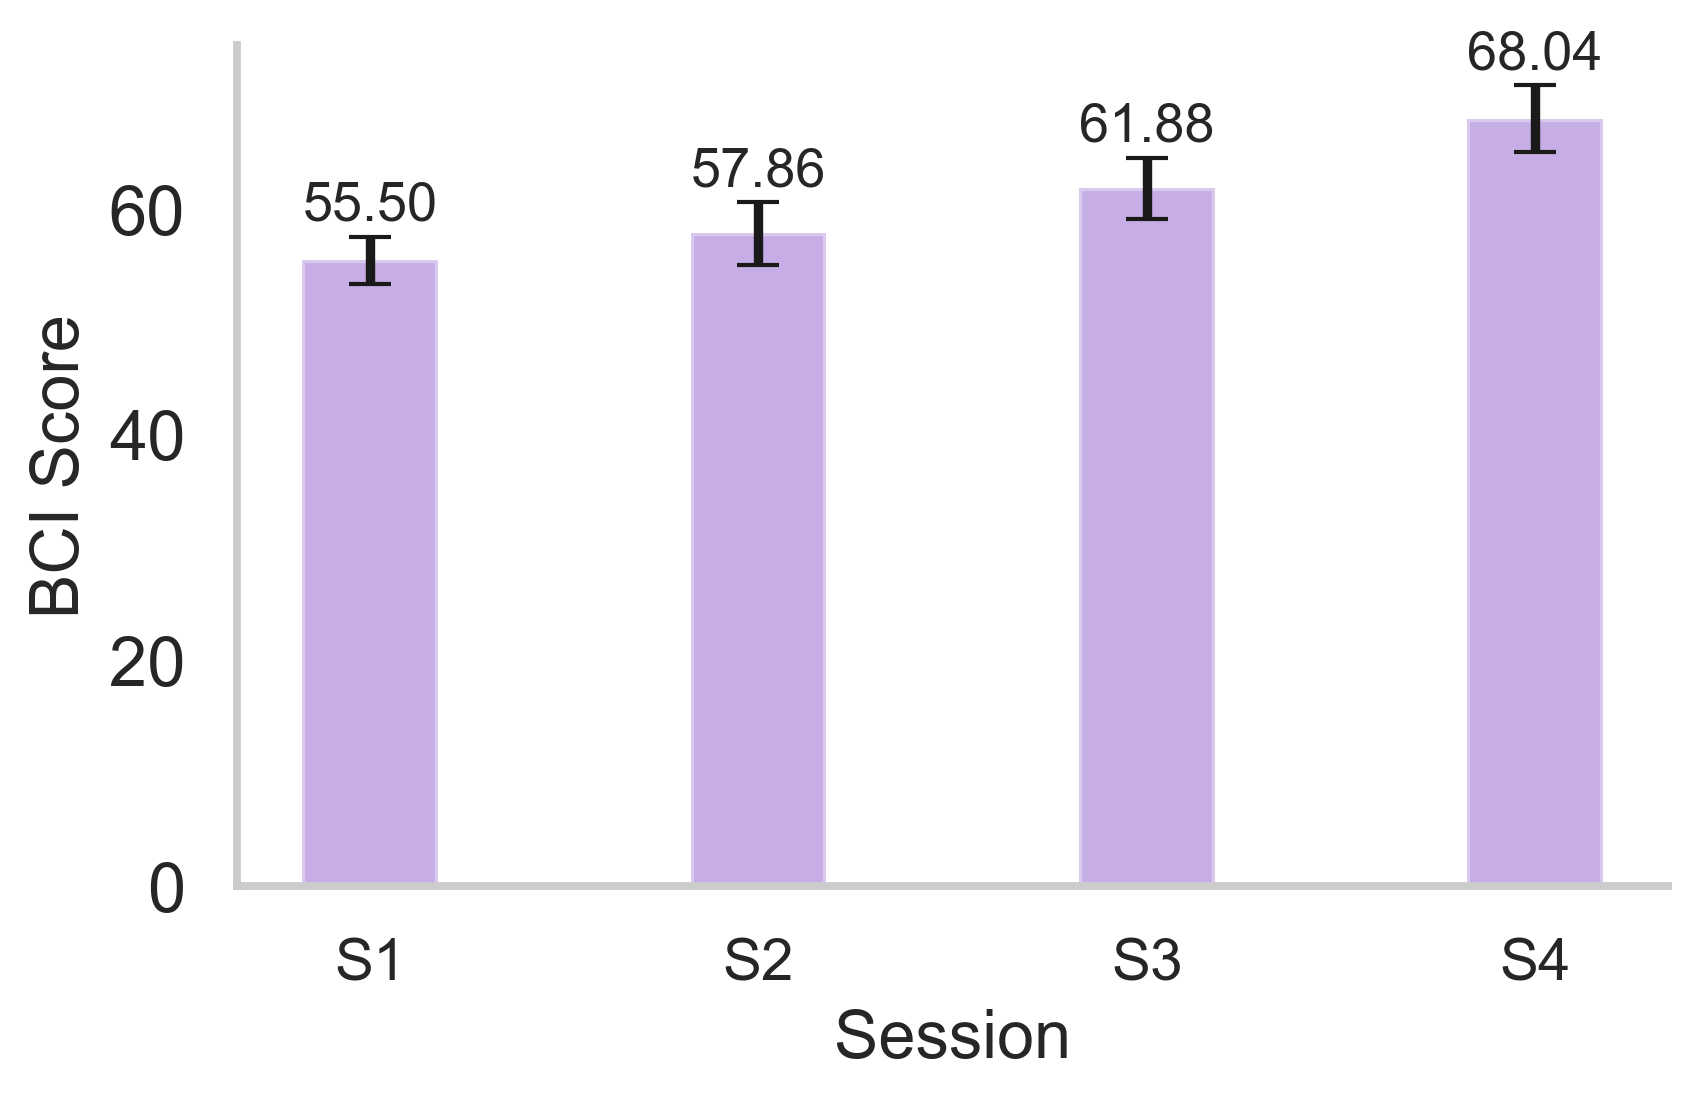

In [320]:
# Plot
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

bars = ax.bar(
    x,
    means,
    yerr=sems,
    capsize=5,
    width=0.35,
    color="#5F14B5",
    alpha=0.35
)

# Annotate mean values
for xi, m, s in zip(x, means, sems):
    ax.text(
        xi,
        m + s + 0.5,   # move text above error bar
        f"{m:.2f}",
        ha="center",
        va="bottom",
        fontsize=13
    )


# Formatting
ax.set_xticks(x)
# ax.set_xticklabels(["1", "2", "3", "4"], fontsize=14)
ax.set_xticklabels(session_labels, fontsize=14)
ax.set_ylabel("BCI Score", fontsize=16)
ax.set_xlabel("Session", fontsize=16)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()

plt.savefig(f'/Users/apurbadebnath/Desktop/bci_score.png', dpi=300)
plt.show()


In [323]:
bci_score[3].mean()

61.8821052631579